# **Feature Learning Kernel Machines for Tabular Data: An Evaluation of xRFM**

---



This notebook implements the full experiment for evaluating xRFM on tabular datasets. To begin with, it loads the datasets, defines the goal, and prepares the data. The project then compares three models, which are Random Forest, XGBoost, and xRFM. Each model is tuned using validation set performance, with classification models evaluated using Accuracy and AUC, and regression models evaluated using RMSE.

After selecting the best hyperparameters, the notebook tests each model on held-out test data and records performance, training time, and inference time per sample. It also includes an interpretability analysis on the e-commerce dataset, comparing PCA importance, mutual information, permutation importance, and xRFM AGOP/GOP diagonal importance. Finally, the notebook includes a scalability experiment that studies how model performance and training time change as the training set size increases.

### Google Colab Environment Setup and Package Installation:

---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost

In [3]:
%cd /content/drive/MyDrive/group

/content/drive/MyDrive/group


In [4]:
!pip install xrfm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 3.4 MB/s eta 0:00:00


### Datasets and Basic Settings:

---



* Here we listed all the datasets used in the project and set the main experiment settings.
* This includes the file location, goal, task type, columns to remove.
* Random seed and train/validation/test split sizes are initialized in the end.

In [5]:
DATASETS = {
    "airline": {
        "file": "data/airline.csv",
        "goal": "satisfaction",
        "type": "classification",
        "drop": ["Unnamed: 0", "id"]
    },
    "ecommerce": {
        "file": "data/ecommerce.csv",
        "goal": "Reached.on.Time_Y.N",
        "type": "classification",
        "drop": ["ID"]
    },
    "realestate": {
        "file": "data/realestate.csv",
        "goal": "price",
        "type": "regression",
        "drop": []
    },
    "student": {
        "file": "data/student.csv",
        "goal": "Final_Score",
        "type": "regression",
        "drop": ["Student_ID"]
    },
    "superconduct": {
        "file": "data/superconduct.csv",
        "goal": "critical_temp",
        "type": "regression",
        "drop": []
    }
}

SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15

### Loading and Preparing the Datasets:

---



* This function loads each dataset and prepares it for training.
* It removes unnecessary columns and rows with goals.
* It also separates the features from the target and returns the task type.

In [6]:
import pandas as p

def load_data(name):
    data = DATASETS[name]
    dataset = p.read_csv(data["file"])
    for drop in data["drop"]:
        dataset = dataset.drop(columns = [drop], errors = "ignore")

    dataset = dataset.dropna(subset=[data["goal"]])

    if name == "realestate":
        dataset = dataset.sample(n=15000, random_state = SEED)

    X = dataset.drop(columns = [data["goal"]])
    y = dataset[data["goal"]]

    return X, y, data["type"], dataset

### Model Evaluation Functions

---



* These functions help evaluate the models using accuracy, RMSE, and AUC.
* They can also evaluate classification predictions and probability scores.
* Such classification predictions include both binary and multiclass classification.

In [7]:
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score
import numpy as np

def accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def auc(y_true, y_prob):
    return roc_auc_score(y_true, y_prob)


def get_num_classes(y):
    return len(np.unique(np.asarray(y)))

def get_classification_predictions_and_scores(model, X_eval):
    pred = model.predict(X_eval)
    pred = np.asarray(pred)
    if pred.ndim > 1:
        pred_labels = np.argmax(pred, axis=1)
    else:
        pred_labels = pred.ravel()
    prob = None
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_eval)
        prob = np.asarray(prob)
        if prob.ndim == 1:
            prob = np.column_stack([1 - prob, prob])
        if prob.ndim == 2 and prob.shape[1] == 1:
            prob = np.column_stack([1 - prob[:, 0], prob[:, 0]])
    return pred_labels, prob

def auc_metric_multiclass(y_true, prob):
    y_true = np.asarray(y_true)
    if prob is None:
        return np.nan
    prob = np.asarray(prob)
    n_classes = get_num_classes(y_true)
    if n_classes == 2:
        if prob.ndim == 2:
            return roc_auc_score(y_true, prob[:, 1])
        return roc_auc_score(y_true, prob)
    return roc_auc_score(
        y_true,
        prob,
        multi_class="ovr",
        average="macro"
    )

### Model Setup Functions:

---



* These functions create the three models used in the project.
* Random Forest, XGBoost, and xRFM.
* Depending on the task type, the classifier or regressor is chosen.

In [8]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from xrfm import xRFM

def RandomForestModel(task, params=None):
    params = params or {}
    if task == "classification":
        return RandomForestClassifier(
            random_state=SEED,
            **params
        )
    else:
        return RandomForestRegressor(
            random_state=SEED,
            **params
        )

def XGBoostModel(task, params=None):
    params = params or {}
    if task == "classification":
        return XGBClassifier(
            random_state=SEED,
            eval_metric="logloss",
            **params
        )
    else:
        return XGBRegressor(
            random_state=SEED,
            **params
        )

def XRFMModel(task, params=None):
    params = params or {}
    base = {
        "random_state": SEED,
    }
    if task == "classification":
        base["tuning_metric"] = "accuracy"
    else:
        base["tuning_metric"] = "mse"
    base.update(params)
    return xRFM(**base)

### Preprocessing the Features:

---



* This function prepares the features before we start training.
* Numerical columns are filled with the median and scaled.
* Categorical columns are filled with the most common value and one-hot encoded.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def onehot():
    try:
        return OneHotEncoder(
            handle_unknown = "ignore",
            max_categories = 50,
            sparse_output = True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown = "ignore",
            max_categories = 50,
            sparse = True
        )


def make_preprocessor(X):
    number_cols = X.select_dtypes(include = ["int64", "float64"]).columns.tolist()
    category_cols = X.select_dtypes(include = ["object", "category", "bool"]).columns.tolist()
    numberp = Pipeline([
        ("missing", SimpleImputer(strategy = "median")),
        ("scale", StandardScaler())
    ])
    categoryp = Pipeline([
        ("missing", SimpleImputer(strategy = "most_frequent")),
        ("onehot", onehot())
    ])
    preprocessor = ColumnTransformer([
        ("numbers", numberp, number_cols),
        ("categories", categoryp, category_cols)
    ])
    return preprocessor, number_cols, category_cols

### Training and Evaluating All Models:

---



* THIS IS DONE FOR TESTING (not needed for the experiment)
* It splits the data into training, validation, and test sets.
* It preprocesses the features, then it trains Random Forest, XGBoost, and xRFM.
* It then evaluates their performance and records training and testing time.
* It saves all results into a CSV file.

In [10]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def to_dense(X):
      if hasattr(X, "toarray"):
          return X.toarray()
      return X

testOld = False
if testOld:

  def to_dense(X):
      if hasattr(X, "toarray"):
          return X.toarray()
      return X

  results = []

  for name in DATASETS:
      try:
          X, y, task, dataset = load_data(name)
          if task == "classification":

              X_rand, X_test, y_rand, y_test = train_test_split(
                  X,
                  y,
                  test_size = TEST_SIZE,
                  random_state = SEED,
                  stratify = y
              )
              val = VAL_SIZE / (1 - TEST_SIZE)
              X_train, X_val, y_train, y_val = train_test_split(
                  X_rand,
                  y_rand,
                  test_size = val,
                  random_state = SEED,
                  stratify = y_rand
              )
              label_encoder = LabelEncoder()
              y_train = label_encoder.fit_transform(y_train)
              y_val = label_encoder.transform(y_val)
              y_test = label_encoder.transform(y_test)

          else:
              X_rand, X_test, y_rand, y_test = train_test_split(
                  X, y,
                  test_size = TEST_SIZE,
                  random_state = SEED
              )
              val = VAL_SIZE / (1 - TEST_SIZE)
              X_train, X_val, y_train, y_val = train_test_split(
                  X_rand,
                  y_rand,
                  test_size = val,
                  random_state = SEED
              )
          preprocessor, number_cols, category_cols = make_preprocessor(X_train)
          X_train_ready = preprocessor.fit_transform(X_train)
          X_val_ready = preprocessor.transform(X_val)
          X_test_ready = preprocessor.transform(X_test)

          #RandomForest
          rfm = RandomForestModel(task, {"n_estimators": 100, "max_depth": None, "min_samples_split": 2})
          start_train_rf = time.time()
          rfm.fit(X_train_ready, y_train)
          end_train_rf = time.time()
          train_time_rf = end_train_rf - start_train_rf
          val_pred_rf = rfm.predict(X_val_ready)
          start_test_rf = time.time()
          test_pred_rf = rfm.predict(X_test_ready)
          end_test_rf = time.time()
          test_time_psample_rf = (end_test_rf - start_test_rf) / len(X_test)
          if task == "classification":
              val_prob_rf = rfm.predict_proba(X_val_ready)[:, 1]
              test_prob_rf = rfm.predict_proba(X_test_ready)[:, 1]
              val_score_rf = accuracy(y_val, val_pred_rf)
              test_score_rf = accuracy(y_test, test_pred_rf)
              val_auc_rf = auc(y_val, val_prob_rf)
              test_auc_rf = auc(y_test, test_prob_rf)
          else:
              val_score_rf = rmse(y_val, val_pred_rf)
              test_score_rf = rmse(y_test, test_pred_rf)
          if task == "classification":
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "RandomForest",
                  "val_acc": val_score_rf,
                  "test_acc": test_score_rf,
                  "val_auc": val_auc_rf,
                  "test_auc": test_auc_rf,
                  "train_time": train_time_rf,
                  "test_time_psample": test_time_psample_rf
              })
          else:
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "RandomForest",
                  "val_rmse": val_score_rf,
                  "test_rmse": test_score_rf,
                  "train_time": train_time_rf,
                  "test_time_psample": test_time_psample_rf
              })

          #XGBoost
          xgb = XGBoostModel(task, {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 4})
          start_train_xg = time.time()
          xgb.fit(X_train_ready, y_train)
          end_train_xg = time.time()
          train_time_xg = end_train_xg - start_train_xg
          val_pred_xg = xgb.predict(X_val_ready)
          start_test_xg = time.time()
          test_pred_xg = xgb.predict(X_test_ready)
          end_test_xg = time.time()
          test_time_psample_xg = (end_test_xg - start_test_xg) / len(X_test)
          if task == "classification":
              val_prob_xg = xgb.predict_proba(X_val_ready)[:, 1]
              test_prob_xg = xgb.predict_proba(X_test_ready)[:, 1]
              val_score_xg = accuracy(y_val, val_pred_xg)
              test_score_xg = accuracy(y_test, test_pred_xg)
              val_auc_xg = auc(y_val, val_prob_xg)
              test_auc_xg = auc(y_test, test_prob_xg)
          else:
              val_score_xg = rmse(y_val, val_pred_xg)
              test_score_xg = rmse(y_test, test_pred_xg)
          if task == "classification":
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "XGBoost",
                  "val_acc": val_score_xg,
                  "test_acc": test_score_xg,
                  "val_auc": val_auc_xg,
                  "test_auc": test_auc_xg,
                  "train_time": train_time_xg,
                  "test_time_psample": test_time_psample_xg
              })
          else:
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "XGBoost",
                  "val_rmse": val_score_xg,
                  "test_rmse": test_score_xg,
                  "train_time": train_time_xg,
                  "test_time_psample": test_time_psample_xg
              })

          #XRFM
          xrfm = XRFMModel(task, {"max_leaf_size": 5000, "n_trees": 1, "n_tree_iters": 0})
          X_train_fit = to_dense(X_train_ready).astype(np.float32)
          X_val_fit = to_dense(X_val_ready).astype(np.float32)
          X_test_fit = to_dense(X_test_ready).astype(np.float32)
          if task == "classification":
              y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1)
              y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1)
          else:
              y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1).astype(np.float32)
              y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)
          start_train_xrf = time.time()
          xrfm.fit(X_train_fit, y_train_fit, X_val_fit, y_val_fit)
          end_train_xrf = time.time()
          train_time_xrf = end_train_xrf - start_train_xrf
          val_pred_xrf = xrfm.predict(X_val_fit)
          start_test_xrf = time.time()
          test_pred_xrf = xrfm.predict(X_test_fit)
          end_test_xrf = time.time()
          test_time_psample_xrf = (end_test_xrf - start_test_xrf) / len(X_test)
          if task == "classification":
              if len(np.shape(val_pred_xrf)) > 1:
                  val_pred_xrf = np.argmax(val_pred_xrf, axis=1)
              if len(np.shape(test_pred_xrf)) > 1:
                  test_pred_xrf = np.argmax(test_pred_xrf, axis=1)

              val_prob_xrf = xrfm.predict_proba(X_val_fit)[:, 1]
              test_prob_xrf = xrfm.predict_proba(X_test_fit)[:, 1]
              val_score_xrf = accuracy(y_val, val_pred_xrf)
              test_score_xrf = accuracy(y_test, test_pred_xrf)
              val_auc_xrf = auc(y_val, val_prob_xrf)
              test_auc_xrf = auc(y_test, test_prob_xrf)
          else:
              val_score_xrf = rmse(y_val, val_pred_xrf)
              test_score_xrf = rmse(y_test, test_pred_xrf)
          if task == "classification":
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "xRFM",
                  "val_acc": val_score_xrf,
                  "test_acc": test_score_xrf,
                  "val_auc": val_auc_xrf,
                  "test_auc": test_auc_xrf,
                  "train_time": train_time_xrf,
                  "test_time_psample": test_time_psample_xrf
              })
          else:
              results.append({
                  "dataset": name,
                  "task": task,
                  "model": "xRFM",
                  "val_rmse": val_score_xrf,
                  "test_rmse": test_score_xrf,
                  "train_time": train_time_xrf,
                  "test_time_psample": test_time_psample_xrf
              })

          #Printing for checking purposes
          print("-" * 40)
          print("Dataset: ", name)
          print("Type: ", task)
          print("Size: ", dataset.shape)
          print("Train:", X_train.shape, y_train.shape)
          print("Val:", X_val.shape, y_val.shape)
          print("Test:", X_test.shape, y_test.shape)
          print("Goal: ", y.name)
          print("Columns (first 10): ", dataset.columns.tolist()[:10])
          print("Numerical columns: ", len(number_cols))
          print("Categorical columns: ", len(category_cols))
          print("Processed train shape: ", X_train_ready.shape)
          print("Processed val shape: ", X_val_ready.shape)
          print("Processed test shape: ", X_test_ready.shape)
          print("RF pred Val: ", val_pred_rf.shape)
          print("RF pred Test: ", test_pred_rf.shape)
          print("XG pred Val: ", val_pred_xg.shape)
          print("XG pred Test: ", test_pred_xg.shape)
          print("xRFM pred Val: ", val_pred_xrf.shape)
          print("xRFM pred Test: ", test_pred_xrf.shape)
          if task == "classification":
              print("RF val ACC:", val_score_rf)
              print("RF test ACC:", test_score_rf)
              print("RF val AUC:", val_auc_rf)
              print("RF test AUC:", test_auc_rf)
              print("XG val ACC:", val_score_xg)
              print("XG test ACC:", test_score_xg)
              print("XG val AUC:", val_auc_xg)
              print("XG test AUC:", test_auc_xg)
              print("xRFM val ACC:", val_score_xrf)
              print("xRFM test ACC:", test_score_xrf)
              print("xRFM val AUC:", val_auc_xrf)
              print("xRFM test AUC:", test_auc_xrf)
          else:
              print("RF val RMSE:", val_score_rf)
              print("RF test RMSE:", test_score_rf)
              print("XG val RMSE:", val_score_xg)
              print("XG test RMSE:", test_score_xg)
              print("xRFM val RMSE:", val_score_xrf)
              print("xRFM test RMSE:", test_score_xrf)
          print("RF train time:", train_time_rf)
          print("RF test time per sample:", test_time_psample_rf)
          print("XG train time:", train_time_xg)
          print("XG test time per sample:", test_time_psample_xg)
          print("xRFM train time:", train_time_xrf)
          print("xRFM test time per sample:", test_time_psample_xrf)
      except Exception as error:
          print("-" * 40)
          print("Dataset: ", name)
          print("Error: ", error)

  results_df = pd.DataFrame(results)
  results_df.to_csv("results.csv", index=False)
  print(results_df)

### Hyperparameter Settings for Model Tuning:

---



* This section shows the different hyperparameter combinations tested for each model.
* These settings help compare different versions of Random Forest, XGBoost, and xRFM in a fair way.

In [11]:
PARAM_GRIDS = {
    "RandomForest": {
        "classification": [
            {"n_estimators": 100, "max_depth": None, "min_samples_split": 2},
            {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2},
            {"n_estimators": 300, "max_depth": 20, "min_samples_split": 5},
        ],
        "regression": [
            {"n_estimators": 100, "max_depth": None, "min_samples_split": 2},
            {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2},
            {"n_estimators": 300, "max_depth": 20, "min_samples_split": 5},
        ],
    },

    "XGBoost": {
        "classification": [
            {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 4},
            {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6},
            {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 8},
        ],
        "regression": [
            {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 4},
            {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6},
            {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 8},
        ],
    },

    "xRFM": {
        "classification": [
            {"max_leaf_size": 2000, "n_trees": 1, "n_tree_iters": 0},
            {"max_leaf_size": 5000, "n_trees": 1, "n_tree_iters": 0},
        ],
        "regression": [
            {"max_leaf_size": 2000, "n_trees": 1, "n_tree_iters": 0},
            {"max_leaf_size": 5000, "n_trees": 1, "n_tree_iters": 0},
        ],
    }

}

### Testing Model Settings on the Validation Set:

---



* This function trains a model using a given set of hyperparameters
* It then evaluates it on the validation set.
* It returns the trained model, the main validation score, the auc score for classification tasks, and the training time.

In [12]:
def evaluate_on_validation(model_name, task,
                           X_train_ready, y_train,
                           X_val_ready, y_val,
                           params):

    if model_name == "RandomForest":
        model = RandomForestModel(task, params)
    elif model_name == "XGBoost":
        model = XGBoostModel(task, params)
    elif model_name == "xRFM":
        model = XRFMModel(task, params)
    else:
        raise ValueError("Unknown model")
    start_train = time.time()

    if model_name == "xRFM":
        X_train_fit = to_dense(X_train_ready).astype(np.float32)
        X_val_fit = to_dense(X_val_ready).astype(np.float32)
        y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1).astype(np.float32)
        y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)
        model.fit(X_train_fit, y_train_fit, X_val_fit, y_val_fit)
        end_train = time.time()
        train_time = end_train - start_train

        if task == "classification":
            val_pred, val_prob = get_classification_predictions_and_scores(
                model,
                X_val_fit
            )
            score_main = accuracy(y_val, val_pred)
            score_aux = auc_metric_multiclass(y_val, val_prob)

        else:
            val_pred = model.predict(X_val_fit)
            if hasattr(val_pred, "shape") and len(val_pred.shape) > 1:
                val_pred = val_pred.ravel()
            score_main = rmse(y_val, val_pred)
            score_aux = None

    else:
        model.fit(X_train_ready, y_train)
        end_train = time.time()
        train_time = end_train - start_train
        if task == "classification":
            val_pred, val_prob = get_classification_predictions_and_scores(
                model,
                X_val_ready
            )
            score_main = accuracy(y_val, val_pred)
            score_aux = auc_metric_multiclass(y_val, val_prob)

        else:
            val_pred = model.predict(X_val_ready)
            score_main = rmse(y_val, val_pred)
            score_aux = None

    return model, score_main, score_aux, train_time

### Hyperparameter Tuning and Best Model Selection:

---



* This function tests all hyperparameter settings for one model and chooses the best version using the validation set.
* For classification, it selects the model with the highest validation AUC.
* For regression, it selects the model with the lowest validation RMSE.

In [13]:
def tune_model(model_name, task,
               X_train_ready, y_train,
               X_val_ready, y_val):

    candidates = PARAM_GRIDS[model_name][task]
    best_model = None
    best_params = None
    best_result = None

    for params in candidates:
        try:
            model, score_main, score_aux, train_time = evaluate_on_validation(
                model_name, task,
                X_train_ready, y_train,
                X_val_ready, y_val,
                params
            )
        except Exception as e:
            print(f"The model {model_name} failed with params = {params}: {e}")
            continue

        if task == "classification":
            current_value = score_aux
            better = (best_result is None) or (current_value > best_result["val_auc"])
            result = {
                "val_acc": score_main,
                "val_auc": score_aux,
                "train_time": train_time
            }
        else:
            current_value = score_main
            better = (best_result is None) or (current_value < best_result["val_rmse"])
            result = {
                "val_rmse": score_main,
                "train_time": train_time
            }
        print(f"{model_name} | params={params} | result={result}")

        if better:
            best_model = model
            best_params = params
            best_result = result

    if best_model is None:
        raise RuntimeError(f"All {model_name} parameters settings have failed for {task}")

    return best_model, best_params, best_result

### Running Hyperparameter Tuning for One Dataset:

---



* This function runs the full tuned experiment for one dataset.
* It splits the data into train, validation, and test sets.
* It then applies preprocessing, tunes each model on the validation set, evaluates the best version on the test set, and saves the tuned results into a CSV file.

In [14]:
def run_one_dataset_tuning(dataset_name):
    X, y, task, dataset = load_data(dataset_name)

    if task == "classification":
        X_rand, X_test, y_rand, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=y
        )
        val_ratio = VAL_SIZE / (1 - TEST_SIZE)
        X_train, X_val, y_train, y_val = train_test_split(
            X_rand,
            y_rand,
            test_size=val_ratio,
            random_state=SEED,
            stratify=y_rand
        )
        label_encoder = LabelEncoder()
        y_train = label_encoder.fit_transform(y_train)
        y_val = label_encoder.transform(y_val)
        y_test = label_encoder.transform(y_test)

    else:
        X_rand, X_test, y_rand, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            random_state=SEED
        )
        val_ratio = VAL_SIZE / (1 - TEST_SIZE)
        X_train, X_val, y_train, y_val = train_test_split(
            X_rand,
            y_rand,
            test_size=val_ratio,
            random_state=SEED
        )

    preprocessor, numeric_cols, categorical_cols = make_preprocessor(X_train)
    X_train_ready = preprocessor.fit_transform(X_train)
    X_val_ready = preprocessor.transform(X_val)
    X_test_ready = preprocessor.transform(X_test)
    rows = []

    for model_name in ["RandomForest", "XGBoost", "xRFM"]:
        print("-" * 40)
        print("Dataset:", dataset_name)
        print("Model:", model_name)
        best_model, best_params, best_result = tune_model(
            model_name,
            task,
            X_train_ready,
            y_train,
            X_val_ready,
            y_val
        )
        if model_name == "xRFM":
            X_test_eval = to_dense(X_test_ready).astype(np.float32)
        else:
            X_test_eval = X_test_ready
        start_test = time.time()
        test_pred = best_model.predict(X_test_eval)
        test_time_psample = (time.time() - start_test) / len(X_test)
        row = {
            "dataset": dataset_name,
            "task": task,
            "model": model_name,
            "best_params": best_params,
            "train_time": best_result["train_time"],
            "test_time_psample": test_time_psample,
        }

        if task == "classification":
            test_pred, test_prob = get_classification_predictions_and_scores(
                best_model,
                X_test_eval
            )
            row.update({
                "val_acc": best_result["val_acc"],
                "val_auc": best_result["val_auc"],
                "test_acc": accuracy(y_test, test_pred),
                "test_auc": auc_metric_multiclass(y_test, test_prob),
            })
        else:
            if hasattr(test_pred, "shape") and len(test_pred.shape) > 1:
                test_pred = test_pred.ravel()
            row.update({
                "val_rmse": best_result["val_rmse"],
                "test_rmse": rmse(y_test, test_pred),
            })
        rows.append(row)
        print(row)

    df = pd.DataFrame(rows)
    df.to_csv(f"{BASE}/results_tuned_{dataset_name}.csv", index=False)
    print("saved:", f"{BASE}/results_tuned_{dataset_name}.csv")

    return df

### Running All Experiments and Combining Results:

---



* This section runs the tuned experiment for each dataset.
* Each dataset result is saved in a CSV file.
* Then all result files are combined into one final results table.
* After that, the best hyperparameters selected for each dataset and model are displayed.

In [15]:
BASE = "/content/drive/MyDrive/group"

In [16]:
df_ecommerce = run_one_dataset_tuning("ecommerce")
df_ecommerce

----------------------------------------
Dataset: ecommerce
Model: RandomForest
RandomForest | params={'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | result={'val_acc': 0.6478787878787878, 'val_auc': np.float64(0.7118536219145976), 'train_time': 1.994873285293579}
RandomForest | params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2} | result={'val_acc': 0.6533333333333333, 'val_auc': np.float64(0.7085088136917405), 'train_time': 2.4682271480560303}
RandomForest | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | result={'val_acc': 0.636969696969697, 'val_auc': np.float64(0.711253936863693), 'train_time': 8.100645303726196}
{'dataset': 'ecommerce', 'task': 'classification', 'model': 'RandomForest', 'best_params': {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}, 'train_time': 1.994873285293579, 'test_time_psample': 3.4364498022830845e-05, 'val_acc': 0.6478787878787878, 'val_auc': np.float64(0.7118536219145976), 'tes

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7314, 19]) y_train torch.Size([7314, 1]) X_val torch.Size([385, 19]) y_val torch.Size([385, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([3657, 19]) y_train torch.Size([3657, 1]) X_val torch.Size([193, 19]) y_val torch.Size([193, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been ma

Building trees: 100%|██████████| 1/1 [00:03<00:00,  3.65s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


...

Building trees: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 149.41it/s]


Selected split_temperature=0.3845258471900222 based on validation accuracy=0.656364
xRFM | params={'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_acc': 0.6557575757575758, 'val_auc': np.float64(0.714186747723333), 'train_time': 1.8455994129180908}
{'dataset': 'ecommerce', 'task': 'classification', 'model': 'xRFM', 'best_params': {'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_iters': 0}, 'train_time': 4.021403074264526, 'test_time_psample': 6.350892962831439e-06, 'val_acc': 0.6703030303030303, 'val_auc': np.float64(0.7314151041285188), 'test_acc': 0.6278787878787879, 'test_auc': np.float64(0.7065554749818709)}
saved: /content/drive/MyDrive/group/results_tuned_ecommerce.csv


,dataset,task,model,best_params,train_time,test_time_psample,val_acc,val_auc,test_acc,test_auc
0,ecommerce,classification,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",1.994873,0.000034,0.647879,0.711854,0.653939,0.735661
1,ecommerce,classification,XGBoost,"{'n_estimators': 100, 'learning_rate': 0.1, 'm...",1.262812,0.000010,0.649091,0.715694,0.672121,0.739053
2,ecommerce,classification,xRFM,"{'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_...",4.021403,0.000006,0.670303,0.731415,0.627879,0.706555


In [17]:
df_student = run_one_dataset_tuning("student")
df_student

----------------------------------------
Dataset: student
Model: RandomForest
RandomForest | params={'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | result={'val_rmse': np.float64(6.687886557472772), 'train_time': 5.757262945175171}
RandomForest | params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2} | result={'val_rmse': np.float64(6.7294566341257855), 'train_time': 7.852534532546997}
RandomForest | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | result={'val_rmse': np.float64(6.670202743922318), 'train_time': 15.58264970779419}
{'dataset': 'student', 'task': 'regression', 'model': 'RandomForest', 'best_params': {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5}, 'train_time': 15.58264970779419, 'test_time_psample': 8.549769719441732e-05, 'val_rmse': np.float64(6.670202743922318), 'test_rmse': np.float64(7.009319620438348)}
----------------------------------------
Dataset: student
Model: XGBoost
XGBoost | params={'n

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([5320, 29]) y_train torch.Size([5320, 1]) X_val torch.Size([280, 29]) y_val torch.Size([280, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([2660, 29]) y_train torch.Size([2660, 1]) X_val torch.Size([140, 29]) y_val torch.Size([140, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1330, 29]) y_train torch.Size([1330, 1]) X_val torch.Size([70, 29]) y_val torch.Size([70, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1330, 29]) y_train torch.Size([1330, 1]) X_val torch.Size([70, 29]) y_val torch.Size([70, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been ma

Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 133.27it/s]


Selected split_temperature=0.29256810906759584 based on validation mse=39.234619
xRFM | params={'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_rmse': np.float64(6.263754435079142), 'train_time': 1.4237380027770996}
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([5320, 29]) y_train torch.Size([5320, 1]) X_val torch.Size([280, 29]) y_val torch.Size([280, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 367.50it/s]


Selected split_temperature=0.3845258471900222 based on validation mse=40.310543
xRFM | params={'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_rmse': np.float64(6.34905849726379), 'train_time': 0.7573070526123047}
{'dataset': 'student', 'task': 'regression', 'model': 'xRFM', 'best_params': {'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_iters': 0}, 'train_time': 1.4237380027770996, 'test_time_psample': 6.846785545349121e-06, 'val_rmse': np.float64(6.263754435079142), 'test_rmse': np.float64(6.49832525242734)}
saved: /content/drive/MyDrive/group/results_tuned_student.csv


,dataset,task,model,best_params,train_time,test_time_psample,val_rmse,test_rmse
0,student,regression,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",15.582650,0.000085,6.670203,7.009320
1,student,regression,XGBoost,"{'n_estimators': 200, 'learning_rate': 0.05, '...",0.442885,0.000005,6.380691,6.744453
2,student,regression,xRFM,"{'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_...",1.423738,0.000007,6.263754,6.498325


In [18]:
df_realestate = run_one_dataset_tuning("realestate")
df_realestate

----------------------------------------
Dataset: realestate
Model: RandomForest
RandomForest | params={'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | result={'val_rmse': np.float64(1190585.357960986), 'train_time': 65.74082970619202}
RandomForest | params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2} | result={'val_rmse': np.float64(1179140.5176026118), 'train_time': 18.946950435638428}
RandomForest | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | result={'val_rmse': np.float64(926286.9781648086), 'train_time': 82.5399100780487}
{'dataset': 'realestate', 'task': 'regression', 'model': 'RandomForest', 'best_params': {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5}, 'train_time': 82.5399100780487, 'test_time_psample': 6.076272328694662e-05, 'val_rmse': np.float64(926286.9781648086), 'test_rmse': np.float64(902969.3842691496)}
----------------------------------------
Dataset: realestate
Model: XGBoost
XGBoost | pa

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([9975, 160]) y_train torch.Size([9975, 1]) X_val torch.Size([525, 160]) y_val torch.Size([525, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4987, 160]) y_train torch.Size([4987, 1]) X_val torch.Size([263, 160]) y_val torch.Size([263, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([2493, 160]) y_train torch.Size([2493, 1]) X_val torch.Size([132, 160]) y_val torch.Size([132, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1247, 160]) y_train torch.Size([1247, 1]) X_val torch.Size([66, 160]) y_val torch.Size([66, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1246, 160]) y_train torch.Size([12

Building trees: 100%|██████████| 1/1 [00:04<00:00,  4.71s/it]


Refilling validation set, because at least one split has been made.


...

Building trees: 100%|██████████| 1/1 [00:03<00:00,  3.54s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 146.82it/s]


Selected split_temperature=2.6050460688818733 based on validation mse=604684419072.000000
xRFM | params={'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_rmse': np.float64(777614.5738982684), 'train_time': 3.703517436981201}
{'dataset': 'realestate', 'task': 'regression', 'model': 'xRFM', 'best_params': {'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0}, 'train_time': 3.703517436981201, 'test_time_psample': 3.833346896701389e-06, 'val_rmse': np.float64(777614.5738982684), 'test_rmse': np.float64(972395.9139769961)}
saved: /content/drive/MyDrive/group/results_tuned_realestate.csv


,dataset,task,model,best_params,train_time,test_time_psample,val_rmse,test_rmse
0,realestate,regression,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",82.539910,0.000061,926286.978165,902969.384269
1,realestate,regression,XGBoost,"{'n_estimators': 100, 'learning_rate': 0.1, 'm...",0.145814,0.000002,805266.431811,916705.947870
2,realestate,regression,xRFM,"{'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_...",3.703517,0.000004,777614.573898,972395.913977


In [19]:
df_airline = run_one_dataset_tuning("airline")
df_airline

----------------------------------------
Dataset: airline
Model: RandomForest
RandomForest | params={'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | result={'val_acc': 0.9643269600923906, 'val_auc': np.float64(0.9942273372354762), 'train_time': 9.26597261428833}
RandomForest | params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2} | result={'val_acc': 0.9458488387013987, 'val_auc': np.float64(0.990239379079708), 'train_time': 11.686552047729492}
RandomForest | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | result={'val_acc': 0.9625304760682664, 'val_auc': np.float64(0.9942757854443743), 'train_time': 25.47671604156494}
{'dataset': 'airline', 'task': 'classification', 'model': 'RandomForest', 'best_params': {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5}, 'train_time': 25.47671604156494, 'test_time_psample': 4.0023115469649744e-05, 'val_acc': 0.9625304760682664, 'val_auc': np.float64(0.9942757854443743), 'test_acc'

{'dataset': 'airline', 'task': 'classification', 'model': 'XGBoost', 'best_params': {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 8}, 'train_time': 3.0169153213500977, 'test_time_psample': 6.915959133411057e-06, 'val_acc': 0.9624663159245477, 'val_auc': np.float64(0.9950133214133975), 'test_acc': 0.9641986398049531, 'test_auc': np.float64(0.9949482264669783)}
----------------------------------------
Dataset: airline
Model: xRFM
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([28476, 27]) y_train torch.Size([28476, 1]) X_val torch.Size([1499, 27]) y_val torch.Size([1499, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([28453, 27]) y_train torch.Size([28453, 1]) X_val torch.Size([1498, 27]) y_val torch.Size([1498, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([17273, 27]) y_train torch.Size([17273, 1]) X_val torch.Size([910, 27]) y_val torch.Size([910, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([8637, 27]) y_train torch.Size([8637, 1]) X_val torch.Size([455, 27]) y_val torch.Size([455, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4318, 27]) y_train torch.Size([4318, 1]) X_val torch.Size([228, 27]) y_val torch.Size([228, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_

Building trees: 100%|██████████| 1/1 [02:56<00:00, 176.79s/it]


...

Building trees: 100%|██████████| 1/1 [02:58<00:00, 178.46s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:01<00:00, 12.04it/s]


Selected split_temperature=0.043185416697174475 based on validation accuracy=0.957590
xRFM | params={'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_acc': 0.9574618247144874, 'val_auc': np.float64(0.991146626274607), 'train_time': 180.22139644622803}
{'dataset': 'airline', 'task': 'classification', 'model': 'xRFM', 'best_params': {'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_iters': 0}, 'train_time': 178.93853640556335, 'test_time_psample': 5.423647898788188e-06, 'val_acc': 0.9557936609778006, 'val_auc': np.float64(0.991454607682833), 'test_acc': 0.9581675862953933, 'test_auc': np.float64(0.9917933260429675)}
saved: /content/drive/MyDrive/group/results_tuned_airline.csv


,dataset,task,model,best_params,train_time,test_time_psample,val_acc,val_auc,test_acc,test_auc
0,airline,classification,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",25.476716,0.000040,0.962530,0.994276,0.963878,0.994219
1,airline,classification,XGBoost,"{'n_estimators': 300, 'learning_rate': 0.03, '...",3.016915,0.000007,0.962466,0.995013,0.964199,0.994948
2,airline,classification,xRFM,"{'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_...",178.938536,0.000005,0.955794,0.991455,0.958168,0.991793


In [20]:
df_superconduct = run_one_dataset_tuning("superconduct")
df_superconduct

----------------------------------------
Dataset: superconduct
Model: RandomForest
RandomForest | params={'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | result={'val_rmse': np.float64(10.396225758333134), 'train_time': 115.86968874931335}
RandomForest | params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2} | result={'val_rmse': np.float64(11.535021541682674), 'train_time': 141.12323379516602}
RandomForest | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5} | result={'val_rmse': np.float64(10.383577057098293), 'train_time': 315.3394846916199}
{'dataset': 'superconduct', 'task': 'regression', 'model': 'RandomForest', 'best_params': {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5}, 'train_time': 315.3394846916199, 'test_time_psample': 8.173766181013054e-05, 'val_rmse': np.float64(10.383577057098293), 'test_rmse': np.float64(9.221171948870122)}
----------------------------------------
Dataset: superconduct
Model: XGBoost


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([14138, 81]) y_train torch.Size([14138, 1]) X_val torch.Size([745, 81]) y_val torch.Size([745, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7069, 81]) y_train torch.Size([7069, 1]) X_val torch.Size([373, 81]) y_val torch.Size([373, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([3534, 81]) y_train torch.Size([3534, 1]) X_val torch.Size([187, 81]) y_val torch.Size([187, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1767, 81]) y_train torch.Size([1767, 1]) X_val torch.Size([94, 81]) y_val torch.Size([94, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1767, 81]) y_train torch.Size([1767, 1])

Building trees: 100%|██████████| 1/1 [00:09<00:00,  9.11s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


...

Building trees: 100%|██████████| 1/1 [00:08<00:00,  8.43s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 69.96it/s]


Selected split_temperature=0.043185416697174475 based on validation mse=120.357170
xRFM | params={'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0} | result={'val_rmse': np.float64(10.970741522212808), 'train_time': 8.74126124382019}
{'dataset': 'superconduct', 'task': 'regression', 'model': 'xRFM', 'best_params': {'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_iters': 0}, 'train_time': 8.74126124382019, 'test_time_psample': 3.378294104692704e-06, 'val_rmse': np.float64(10.970741522212808), 'test_rmse': np.float64(9.996849807612008)}
saved: /content/drive/MyDrive/group/results_tuned_superconduct.csv


,dataset,task,model,best_params,train_time,test_time_psample,val_rmse,test_rmse
0,superconduct,regression,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",315.339485,0.000082,10.383577,9.221172
1,superconduct,regression,XGBoost,"{'n_estimators': 300, 'learning_rate': 0.03, '...",19.220952,0.000008,10.589262,9.254766
2,superconduct,regression,xRFM,"{'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_...",8.741261,0.000003,10.970742,9.996850


In [21]:
files = [
    f"{BASE}/results_tuned_ecommerce.csv",
    f"{BASE}/results_tuned_student.csv",
    f"{BASE}/results_tuned_realestate.csv",
    f"{BASE}/results_tuned_airline.csv",
    f"{BASE}/results_tuned_superconduct.csv",
]
all_results = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
all_results.to_csv(f"{BASE}/results_tuned_all.csv", index=False)
all_results
all_results.groupby(["dataset", "model"]).size()

dataset       model       
airline       RandomForest    1
              XGBoost         1
              xRFM            1
ecommerce     RandomForest    1
              XGBoost         1
              xRFM            1
realestate    RandomForest    1
              XGBoost         1
              xRFM            1
student       RandomForest    1
              XGBoost         1
              xRFM            1
superconduct  RandomForest    1
              XGBoost         1
              xRFM            1
dtype: int64

In [22]:
hBASE = "/content/drive/MyDrive/group"
all_results = pd.read_csv(f"{BASE}/results_tuned_all.csv")
all_results[["dataset", "model", "best_params"]]


,dataset,model,best_params
0,ecommerce,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_..."
1,ecommerce,XGBoost,"{'n_estimators': 100, 'learning_rate': 0.1, 'm..."
2,ecommerce,xRFM,"{'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_..."
3,student,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."
4,student,XGBoost,"{'n_estimators': 200, 'learning_rate': 0.05, '..."
5,student,xRFM,"{'max_leaf_size': 2000, 'n_trees': 1, 'n_tree_..."
6,realestate,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."
7,realestate,XGBoost,"{'n_estimators': 100, 'learning_rate': 0.1, 'm..."
8,realestate,xRFM,"{'max_leaf_size': 5000, 'n_trees': 1, 'n_tree_..."
9,airline,RandomForest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."


### Helper Functions for Result Analysis:

---



* These helper functions load the tuned results, extract the best hyperparameters.
* It then rebuilds the selected models, and prepares each dataset using the same train, validation, and test split used in the main experiment.

In [23]:
import ast
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.inspection import permutation_importance

BASE = "/content/drive/MyDrive/group"
all_results = pd.read_csv(f"{BASE}/results_tuned_all.csv")

def parse_best_params(dataset_name, model_name):
    row = all_results[
        (all_results["dataset"] == dataset_name) &
        (all_results["model"] == model_name)
    ].iloc[0]
    params = row["best_params"]
    if isinstance(params, str):
        return ast.literal_eval(params)
    return params


def make_model_from_best_params(model_name, task, params):
    if model_name == "RandomForest":
        return RandomForestModel(task, params)
    if model_name == "XGBoost":
        return XGBoostModel(task, params)
    if model_name == "xRFM":
        return XRFMModel(task, params)
    raise ValueError(model_name)


def prepare_dataset_split(dataset_name):
    X, y, task, dataset = load_data(dataset_name)
    if task == "classification":
        stratify_y = y
    else:
        stratify_y = None
    X_rand, X_test, y_rand, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=stratify_y
    )
    val_ratio = VAL_SIZE / (1 - TEST_SIZE)
    if task == "classification":
        stratify_rand = y_rand
    else:
        stratify_rand = None
    X_train, X_val, y_train, y_val = train_test_split(
        X_rand,
        y_rand,
        test_size=val_ratio,
        random_state=SEED,
        stratify=stratify_rand
    )
    if task == "classification":
        label_encoder = LabelEncoder()
        y_train = label_encoder.fit_transform(y_train)
        y_val = label_encoder.transform(y_val)
        y_test = label_encoder.transform(y_test)
    preprocessor, number_cols, category_cols = make_preprocessor(X_train)
    X_train_ready = preprocessor.fit_transform(X_train)
    X_val_ready = preprocessor.transform(X_val)
    X_test_ready = preprocessor.transform(X_test)
    return {
        "X": X,
        "y": y,
        "task": task,
        "dataset": dataset,
        "preprocessor": preprocessor,
        "X_train_ready": X_train_ready,
        "X_val_ready": X_val_ready,
        "X_test_ready": X_test_ready,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }

###Interpretability Experiment:

---



* This section runs the interpretability comparison on the ecommerce dataset.
* It compares xRFM's AGOP feature importance with PCA, mutual information, and permutation importance.
* It then displays the top ranked features.

In [24]:
from sklearn.base import clone

def get_feature_names_from_preprocessor(preprocessor):
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        return [f"feature_{i}" for i in range(preprocessor.transformers_[0][2].shape[0])]


def fit_best_xrfm_for_interpretability(dataset_name):
    data = prepare_dataset_split(dataset_name)
    task = data["task"]
    X_train_ready = data["X_train_ready"]
    X_val_ready = data["X_val_ready"]
    X_test_ready = data["X_test_ready"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    preprocessor = data["preprocessor"]
    params = parse_best_params(dataset_name, "xRFM")
    model = make_model_from_best_params("xRFM", task, params)
    X_train_fit = to_dense(X_train_ready).astype(np.float32)
    X_val_fit = to_dense(X_val_ready).astype(np.float32)
    X_test_fit = to_dense(X_test_ready).astype(np.float32)
    y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1).astype(np.float32)
    y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)
    model.fit(X_train_fit, y_train_fit, X_val_fit, y_val_fit)
    return {
        "model": model,
        "task": task,
        "preprocessor": preprocessor,
        "X_train_ready": X_train_ready,
        "X_val_ready": X_val_ready,
        "X_test_ready": X_test_ready,
        "X_train_fit": X_train_fit,
        "X_test_fit": X_test_fit,
        "y_train": y_train,
        "y_test": y_test,
    }

def extract_xrfm_agop_diagonal(model):
    import torch
    if hasattr(model, "collect_best_agops"):
        agops = model.collect_best_agops()
        if agops is None:
            raise ValueError("collect_best_agops returned None")
        diags = []
        for mat in agops:
            if isinstance(mat, torch.Tensor):
                mat = mat.detach().cpu().numpy()
            if isinstance(mat, np.ndarray) and mat.ndim == 2:
                diags.append(np.diag(mat))
        if len(diags) > 0:
            return np.mean(np.vstack(diags), axis=0)
    raise AttributeError("Could not extract AGOP from xRFM model")

def compute_pca_importance(X_train_ready):
    X_dense = to_dense(X_train_ready)
    pca = PCA(n_components=min(X_dense.shape[1], 10), random_state=SEED)
    pca.fit(X_dense)
    weights = pca.explained_variance_ratio_
    loadings = np.abs(pca.components_)
    importance = (weights[:, None] * loadings).sum(axis=0)
    return importance


def compute_mi_importance(X_train_ready, y_train, task):
    X_dense = to_dense(X_train_ready)
    if task == "classification":
        mi = mutual_info_classif(X_dense, y_train, random_state=SEED)
    else:
        mi = mutual_info_regression(X_dense, y_train, random_state=SEED)
    return np.asarray(mi)


from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin
def compute_permutation_importance_for_xrfm(dataset_name):
    data = prepare_dataset_split(dataset_name)
    task = data["task"]
    X_train_ready = data["X_train_ready"]
    X_val_ready = data["X_val_ready"]
    X_test_ready = data["X_test_ready"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    params = parse_best_params(dataset_name, "xRFM")
    model = make_model_from_best_params("xRFM", task, params)
    X_train_fit = to_dense(X_train_ready).astype(np.float32)
    X_val_fit = to_dense(X_val_ready).astype(np.float32)
    X_test_fit = to_dense(X_test_ready).astype(np.float32)
    y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1).astype(np.float32)
    y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)
    model.fit(X_train_fit, y_train_fit, X_val_fit, y_val_fit)
    if task == "classification":
        class XRFMWrapper(ClassifierMixin, BaseEstimator):
            _estimator_type = "classifier"
            def __init__(self, model):
                self.model = model
                self.classes_ = np.array([0, 1])
            def fit(self, X, y):
                self.classes_ = np.unique(y)
                return self
            def predict(self, X):
                pred = self.model.predict(X)
                if hasattr(pred, "ndim") and pred.ndim > 1:
                    pred = pred.ravel()
                return pred.astype(int)
            def predict_proba(self, X):
                prob = self.model.predict_proba(X)
                prob = np.asarray(prob)
                if prob.ndim == 1:
                    prob = np.column_stack([1 - prob, prob])
                if prob.ndim == 2 and prob.shape[1] == 1:
                    prob = np.column_stack([1 - prob[:, 0], prob[:, 0]])
                return prob
        wrapped = XRFMWrapper(model)
        scoring = "roc_auc"
    else:
        class XRFMWrapper(RegressorMixin, BaseEstimator):
            _estimator_type = "regressor"
            def __init__(self, model):
                self.model = model
            def fit(self, X, y):
                return self
            def predict(self, X):
                pred = self.model.predict(X)
                if hasattr(pred, "ndim") and pred.ndim > 1:
                    pred = pred.ravel()
                return pred
        wrapped = XRFMWrapper(model)
        scoring = "neg_root_mean_squared_error"
    perm = permutation_importance(
        wrapped,
        X_test_fit,
        y_test,
        n_repeats=5,
        random_state=SEED,
        scoring=scoring,
    )
    return perm.importances_mean

def run_interpretability_experiment(dataset_name="ecommerce", top_k=15, save_plot=True):
    fitted = fit_best_xrfm_for_interpretability(dataset_name)
    model = fitted["model"]
    task = fitted["task"]
    preprocessor = fitted["preprocessor"]
    X_train_ready = fitted["X_train_ready"]
    y_train = fitted["y_train"]
    feature_names = get_feature_names_from_preprocessor(preprocessor)
    agop_importance = extract_xrfm_agop_diagonal(model)
    pca_importance = compute_pca_importance(X_train_ready)
    mi_importance = compute_mi_importance(X_train_ready, y_train, task)
    perm_importance = compute_permutation_importance_for_xrfm(dataset_name)
    def normalize(v):
        v = np.asarray(v, dtype=float)
        v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
        if np.max(np.abs(v)) == 0:
            return v
        return np.abs(v) / np.max(np.abs(v))
    result_df = pd.DataFrame({
        "feature": feature_names,
        "AGOP": normalize(agop_importance),
        "PCA": normalize(pca_importance),
        "MI": normalize(mi_importance),
        "Permutation": normalize(perm_importance),
    })

    result_df["mean_score"] = result_df[["AGOP", "PCA", "MI", "Permutation"]].mean(axis=1)
    result_df = result_df.sort_values("mean_score", ascending=False).reset_index(drop=True)
    top_df = result_df.head(top_k).copy()
    plt.figure(figsize=(12, 7))
    x = np.arange(len(top_df))
    width = 0.2
    plt.bar(x - 1.5 * width, top_df["AGOP"], width=width, label="AGOP")
    plt.bar(x - 0.5 * width, top_df["PCA"], width=width, label="PCA")
    plt.bar(x + 0.5 * width, top_df["MI"], width=width, label="MI")
    plt.bar(x + 1.5 * width, top_df["Permutation"], width=width, label="Permutation")
    plt.xticks(x, top_df["feature"], rotation=60, ha="right")
    plt.ylabel("Normalized importance")
    plt.title(f"Interpretability comparison on {dataset_name}")
    plt.legend()
    plt.tight_layout()
    if save_plot:
        plt.savefig(f"{BASE}/interpretability_{dataset_name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    result_df.to_csv(f"{BASE}/interpretability_{dataset_name}.csv", index=False)
    return result_df

Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7314, 19]) y_train torch.Size([7314, 1]) X_val torch.Size([385, 19]) y_val torch.Size([385, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([3657, 19]) y_train torch.Size([3657, 1]) X_val torch.Size([193, 19]) y_val torch.Size([193, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been ma

Building trees: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


...

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7314, 19]) y_train torch.Size([7314, 1]) X_val torch.Size([385, 19]) y_val torch.Size([385, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([3657, 19]) y_train torch.Size([3657, 1]) X_val torch.Size([193, 19]) y_val torch.Size([193, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been ma

Building trees: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 117.74it/s]


Selected split_temperature=0.5053870280955405 based on validation accuracy=0.652121


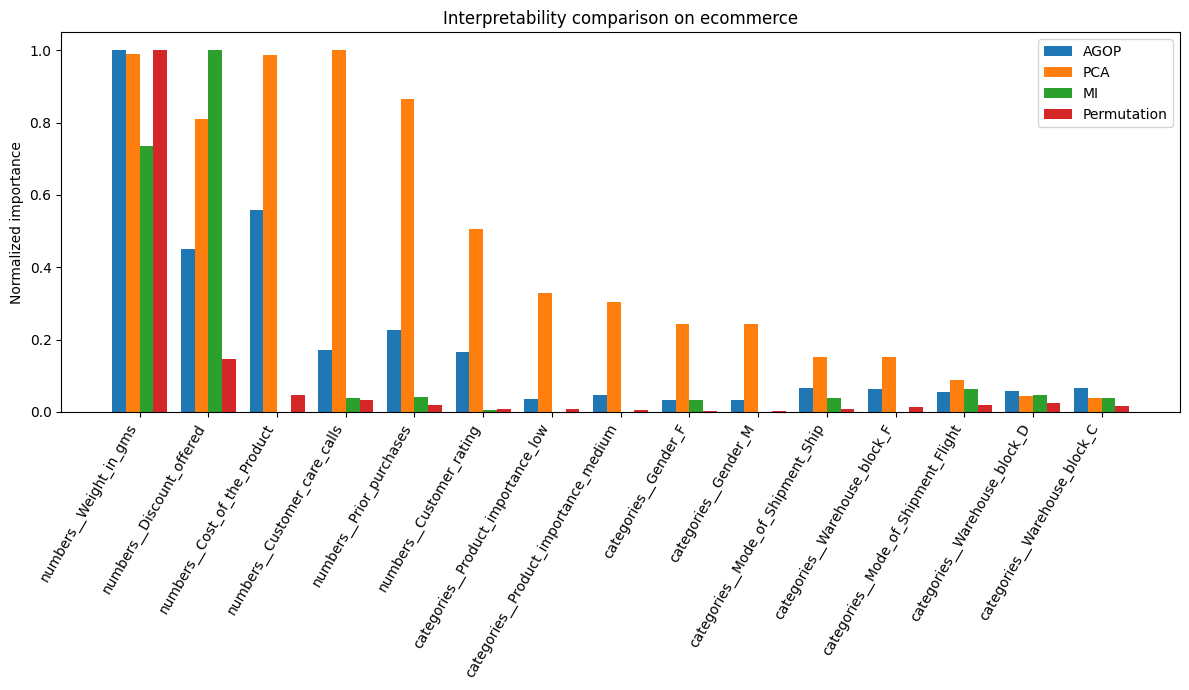

,feature,AGOP,PCA,MI,Permutation,mean_score
0,numbers__Weight_in_gms,1.000000,0.990366,0.734570,1.000000,0.931234
1,numbers__Discount_offered,0.450242,0.810499,1.000000,0.145522,0.601566
2,numbers__Cost_of_the_Product,0.558521,0.987766,0.000000,0.046442,0.398182
3,numbers__Customer_care_calls,0.171245,1.000000,0.037869,0.032202,0.310329
4,numbers__Prior_purchases,0.227102,0.866120,0.041534,0.019561,0.288579
5,numbers__Customer_rating,0.165210,0.505143,0.004248,0.008943,0.170886
6,categories__Product_importance_low,0.035486,0.328604,0.000000,0.006776,0.092717
7,categories__Product_importance_medium,0.047828,0.304325,0.000000,0.006052,0.089551
8,categories__Gender_F,0.033726,0.242588,0.033657,0.001783,0.077939
9,categories__Gender_M,0.033724,0.242588,0.000000,0.001715,0.069507


In [25]:
interp_df = run_interpretability_experiment("ecommerce", top_k=15)
interp_df.head(20)

### Learning Curve and Scalability Experiment:

---



* This part tests how model performance and training time change when using different training set sizes.
* It helps compare how Random Forest, XGBoost, and xRFM scale as more data is added.
* This section plots the learning curve results for the ecommerce dataset.

In [26]:
def run_learning_curve_experiment(dataset_name="ecommerce", train_sizes=(1000, 3000, 6000)):
    data = prepare_dataset_split(dataset_name)

    task = data["task"]
    X_train_ready = data["X_train_ready"]
    X_val_ready = data["X_val_ready"]
    X_test_ready = data["X_test_ready"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    max_train = X_train_ready.shape[0]

    actual_train_sizes = []
    for size in train_sizes:
        if size < max_train:
            actual_train_sizes.append(size)

    actual_train_sizes.append(max_train)
    actual_train_sizes = sorted(set(actual_train_sizes))

    rows = []
    rng = np.random.default_rng(SEED)

    for size in actual_train_sizes:
        idx = rng.choice(max_train, size=size, replace=False)

        X_sub = X_train_ready[idx]
        y_sub = y_train[idx]

        for model_name in ["RandomForest", "XGBoost", "xRFM"]:
            params = parse_best_params(dataset_name, model_name)
            model = make_model_from_best_params(model_name, task, params)

            start_train = time.time()

            if model_name == "xRFM":
                X_sub_fit = to_dense(X_sub).astype(np.float32)
                X_val_fit = to_dense(X_val_ready).astype(np.float32)
                X_test_fit = to_dense(X_test_ready).astype(np.float32)

                y_sub_fit = pd.Series(y_sub).to_numpy().reshape(-1, 1).astype(np.float32)
                y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)

                try:
                    model.fit(X_sub_fit, y_sub_fit, X_val_fit, y_val_fit)
                except Exception as e:
                    print(f"xRFM failed at train_size={size}: {e}")
                    continue

                pred = model.predict(X_test_fit)

                if task == "classification":
                    prob = model.predict_proba(X_test_fit)[:, 1]

            else:
                model.fit(X_sub, y_sub)
                pred = model.predict(X_test_ready)

                if task == "classification":
                    prob = model.predict_proba(X_test_ready)[:, 1]

            train_time = time.time() - start_train

            row = {
                "dataset": dataset_name,
                "train_size": size,
                "model": model_name,
                "train_time": train_time,
            }

            if task == "classification":
                row["test_acc"] = accuracy(y_test, pred)
                row["test_auc"] = auc(y_test, prob)
            else:
                row["test_rmse"] = rmse(y_test, pred)

            rows.append(row)
            print(row)

    learning_curve_df = pd.DataFrame(rows)
    learning_curve_df.to_csv(f"{BASE}/learning_curve_{dataset_name}.csv", index=False)

    return learning_curve_df


learning_curve_df = run_learning_curve_experiment("ecommerce", train_sizes=(1000, 3000, 6000))
learning_curve_df

{'dataset': 'ecommerce', 'train_size': 1000, 'model': 'RandomForest', 'train_time': 0.2724883556365967, 'test_acc': 0.6418181818181818, 'test_auc': np.float64(0.7345780695393305)}
{'dataset': 'ecommerce', 'train_size': 1000, 'model': 'XGBoost', 'train_time': 0.044373273849487305, 'test_acc': 0.6545454545454545, 'test_auc': np.float64(0.7350215640624405)}
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tree has no split, stopping training
{'dataset': 'ecommerce', 'train_size': 1000, 'model': 'xRFM', 'train_time': 0.07868790626525879, 'test_acc': 0.6363636363636364, 'test_auc': np.float64(0.7140674020075568)}


{'dataset': 'ecommerce', 'train_size': 3000, 'model': 'RandomForest', 'train_time': 0.5147304534912109, 'test_acc': 0.6533333333333333, 'test_auc': np.float64(0.7304652494179611)}
{'dataset': 'ecommerce', 'train_size': 3000, 'model': 'XGBoost', 'train_time': 0.05746650695800781, 'test_acc': 0.6630303030303031, 'test_auc': np.float64(0.7274249074462807)}
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

...

Building trees: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 86.64it/s]


Selected split_temperature=0.09804665307775966 based on validation accuracy=0.672121
{'dataset': 'ecommerce', 'train_size': 7699, 'model': 'xRFM', 'train_time': 2.422424077987671, 'test_acc': 0.6521212121212121, 'test_auc': np.float64(0.7330865234151368)}


,dataset,train_size,model,train_time,test_acc,test_auc
0,ecommerce,1000,RandomForest,0.272488,0.641818,0.734578
1,ecommerce,1000,XGBoost,0.044373,0.654545,0.735022
2,ecommerce,1000,xRFM,0.078688,0.636364,0.714067
3,ecommerce,3000,RandomForest,0.514730,0.653333,0.730465
4,ecommerce,3000,XGBoost,0.057467,0.663030,0.727425
5,ecommerce,3000,xRFM,0.601756,0.652727,0.716429
6,ecommerce,6000,RandomForest,0.866020,0.670909,0.742346
7,ecommerce,6000,XGBoost,0.104571,0.661818,0.734544
8,ecommerce,6000,xRFM,1.480841,0.642424,0.714714
9,ecommerce,7699,RandomForest,1.361855,0.665455,0.741230


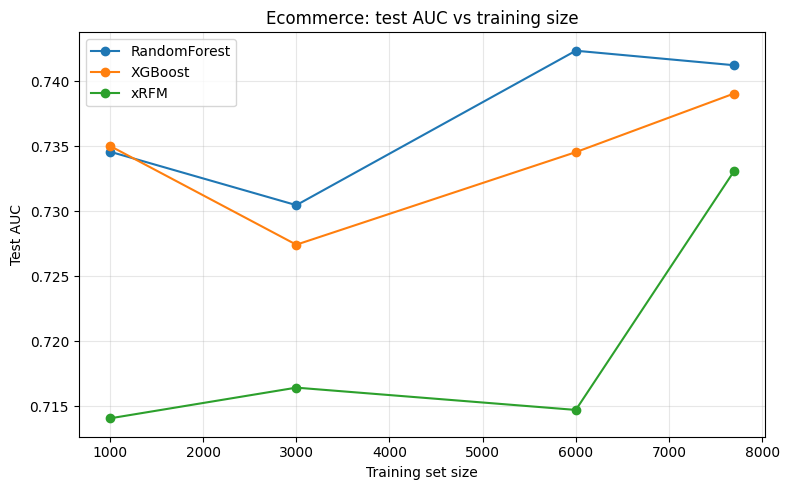

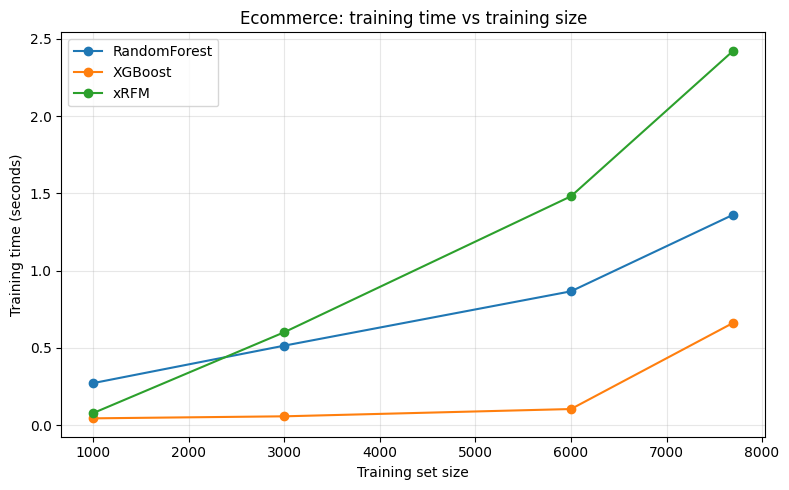

In [27]:
plt.figure(figsize=(8, 5))

for model_name, group in learning_curve_df.groupby("model"):
    group = group.sort_values("train_size")
    plt.plot(group["train_size"], group["test_auc"], marker="o", label=model_name)

plt.xlabel("Training set size")
plt.ylabel("Test AUC")
plt.title("Ecommerce: test AUC vs training size")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/learning_curve_ecommerce_auc.png", dpi=200)
plt.show()


plt.figure(figsize=(8, 5))

for model_name, group in learning_curve_df.groupby("model"):
    group = group.sort_values("train_size")
    plt.plot(group["train_size"], group["train_time"], marker="o", label=model_name)

plt.xlabel("Training set size")
plt.ylabel("Training time (seconds)")
plt.title("Ecommerce: training time vs training size")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/learning_curve_ecommerce_time.png", dpi=200)
plt.show()

### Extracting xRFM AGOP Feature Importance:

---



* These functions search inside the trained xRFM model to find AGOP/GOP matrices.
* The diagonal values of these matrices are used as xRFM feature importance scores.
* The scores are normalised so they can be compared with other importance methods.

In [28]:
def normalized_importance(values):
    values = np.asarray(values, dtype=float)
    values = np.nan_to_num(np.abs(values), nan=0.0, posinf=0.0, neginf=0.0)
    total = values.sum()
    if total > 0:
        return values / total
    return values

def collect_square_matrices(obj, n_features, max_depth=5):
    matrices = []
    seen = set()
    def visit(value, path, depth):
        if depth > max_depth:
            return
        if id(value) in seen:
            return
        seen.add(id(value))
        arr = None
        if hasattr(value, "detach"):
            try:
                arr = value.detach().cpu().numpy()
            except Exception:
                arr = None
        else:
            try:
                arr = np.asarray(value)
            except Exception:
                arr = None
        if arr is not None:
            if getattr(arr, "ndim", None) == 2 and arr.shape == (n_features, n_features):
                matrices.append((path, arr.astype(float)))
                return
        if isinstance(value, dict):
            for key, val in value.items():
                visit(val, f"{path}.{key}", depth + 1)
        elif isinstance(value, (list, tuple)):
            for i, val in enumerate(value):
                visit(val, f"{path}[{i}]", depth + 1)
        elif hasattr(value, "__dict__"):
            for key, val in vars(value).items():
                if not key.startswith("__"):
                    visit(val, f"{path}.{key}", depth + 1)
    visit(obj, "xrfm", 0)
    return matrices

def xrfm_diag_importance(model, n_features):
    matrices = collect_square_matrices(model, n_features)
    if len(matrices) == 0:
        print("No GOP/AGOP square matrix found inside xRFM object.")
        return None
    diagonals = []
    for path, matrix in matrices:
        print("Using xRFM matrix:", path, matrix.shape)
        diagonals.append(np.diag(matrix))
    diag = np.mean(np.vstack(diagonals), axis=0)
    return normalized_importance(diag)

### Interpretability Analysis and Feature Importance Plot:

---



* This section compares feature importance methods on ecommerce dataset.
* It calculates PCA importance, mutual information, permutation importance, and xRFM AGOP/GOP diagonal importance.
* The results are saved into a CSV file.
* A bar chart is created to visualise the most important features.

In [29]:
dataset_name = "ecommerce"
data = prepare_dataset_split(dataset_name)
task = data["task"]
preprocessor = data["preprocessor"]
X_train_ready = data["X_train_ready"]
X_val_ready = data["X_val_ready"]
X_test_ready = data["X_test_ready"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]
feature_names = preprocessor.get_feature_names_out()
X_train_dense = to_dense(X_train_ready).astype(np.float32)
X_val_dense = to_dense(X_val_ready).astype(np.float32)

pca = PCA(
    n_components=min(5, X_train_dense.shape[1]),
    random_state=SEED
)
pca.fit(X_train_dense)
pca_importance = normalized_importance(
    np.average(
        np.abs(pca.components_),
        axis=0,
        weights=pca.explained_variance_ratio_
    )
)

if task == "classification":
    mi_values = mutual_info_classif(
        X_train_dense,
        y_train,
        random_state=SEED
    )
else:
    mi_values = mutual_info_regression(
        X_train_dense,
        y_train,
        random_state=SEED
    )
mi_importance = normalized_importance(mi_values)

xgb_params = parse_best_params(dataset_name, "XGBoost")
xgb_model = XGBoostModel(task, xgb_params)
xgb_model.fit(X_train_ready, y_train)
if task == "classification":
    scoring = "roc_auc"
else:
    scoring = "neg_root_mean_squared_error"
perm = permutation_importance(
    xgb_model,
    X_val_ready,
    y_val,
    n_repeats=5,
    random_state=SEED,
    scoring=scoring
)
permutation_importance_values = normalized_importance(
    perm.importances_mean
)

xrfm_params = parse_best_params(dataset_name, "xRFM")
xrfm_model = XRFMModel(task, xrfm_params)
y_train_fit = pd.Series(y_train).to_numpy().reshape(-1, 1).astype(np.float32)
y_val_fit = pd.Series(y_val).to_numpy().reshape(-1, 1).astype(np.float32)
xrfm_model.fit(
    X_train_dense,
    y_train_fit,
    X_val_dense,
    y_val_fit
)
xrfm_gop_importance = normalized_importance(
    extract_xrfm_agop_diagonal(xrfm_model)
)
interpretability_df = pd.DataFrame({
    "feature": feature_names,
    "pca_importance": pca_importance,
    "mutual_info_importance": mi_importance,
    "permutation_importance": permutation_importance_values,
    "xrfm_agop_diag_importance": xrfm_gop_importance,
})
interpretability_df.to_csv(f"{BASE}/interpretability_ecommerce.csv", index=False)
interpretability_df.sort_values(
    "permutation_importance",
    ascending=False
).head(20)

Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7314, 19]) y_train torch.Size([7314, 1]) X_val torch.Size([385, 19]) y_val torch.Size([385, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([3657, 19]) y_train torch.Size([3657, 1]) X_val torch.Size([193, 19]) y_val torch.Size([193, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([1828, 19]) y_train torch.Size([1828, 1]) X_val torch.Size([97, 19]) y_val torch.Size([97, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been ma

Building trees: 100%|██████████| 1/1 [00:02<00:00,  2.07s/it]


Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 135.93it/s]

Selected split_temperature=0.025000000000000005 based on validation accuracy=0.670909


,feature,pca_importance,mutual_info_importance,permutation_importance,xrfm_agop_diag_importance
4,numbers__Discount_offered,0.126311,0.482863,0.517260,0.140516
5,numbers__Weight_in_gms,0.159571,0.361844,0.249454,0.312089
3,numbers__Prior_purchases,0.171691,0.020055,0.068357,0.070876
2,numbers__Cost_of_the_Product,0.202961,0.000000,0.044743,0.174309
0,numbers__Customer_care_calls,0.179640,0.018286,0.029312,0.053444
14,categories__Product_importance_high,0.005430,0.000203,0.020380,0.009752
11,categories__Mode_of_Shipment_Flight,0.001208,0.030161,0.015626,0.017227
1,numbers__Customer_rating,0.105619,0.002051,0.010164,0.051560
7,categories__Warehouse_block_B,0.002208,0.008498,0.006685,0.017425
10,categories__Warehouse_block_F,0.003074,0.000000,0.006592,0.020012


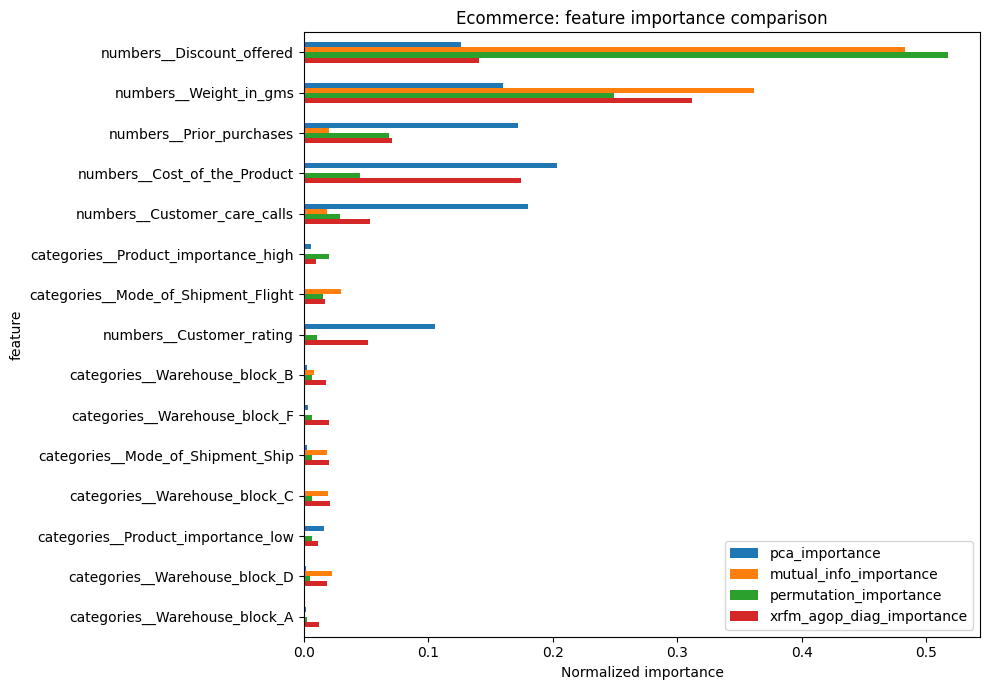

In [30]:
top = interpretability_df.sort_values(
    "permutation_importance",
    ascending=False
).head(15)

plot_cols = [
    "pca_importance",
    "mutual_info_importance",
    "permutation_importance"
]

if top["xrfm_agop_diag_importance"].notna().any():
    plot_cols.append("xrfm_agop_diag_importance")
ax = top.set_index("feature")[plot_cols].plot(
    kind="barh",
    figsize=(10, 7)
)

ax.invert_yaxis()
plt.xlabel("Normalized importance")
plt.title("Ecommerce: feature importance comparison")
plt.tight_layout()
plt.savefig(f"{BASE}/interpretability_ecommerce.png", dpi=200)
plt.show()

In [31]:
!ls /content/drive/MyDrive/group | grep -E "learning_curve|interpretability|results_tuned_all"

interpretability_ecommerce.csv
interpretability_ecommerce.png
learning_curve_ecommerce_auc.png
learning_curve_ecommerce.csv
learning_curve_ecommerce_time.png
results_tuned_all.csv
